<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/Q_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q-Learning

*Description*: En este notebook se desarrolla la implementación del método de **Q-Learning**, y se emplea sobre el entorno Taxi-v3 de Gymnasium.


    Autores: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín

    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
            
    Date: 2026/02/25

Empezamos instalando e importando las librerías necesarias. También definimos los dispositivos donde se ejecutará el notebook y la semilla que vamos a usar para asegurar reproducibilidad.

In [1]:
%%capture
!pip install gymnasium

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc
import os

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SEED = 42

# NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)

Usando dispositivo: cpu


## Agente

Para implementar los distintos métodos de aprendizaje estudiados en la asignatura, hemos seguido las recomendaciones de Gymnasium para la creación de agentes y la generación de episodios, tal como se indicaba en la definición de la práctica. La idea central ha sido encapsular toda la lógica de interacción y aprendizaje en una clase `Agente`, adaptable a los diferentes algoritmos que se desean evaluar.

En este trabajo nos centramos en **Q-Learning**, un método de **Diferencias Temporales (TD)** de tipo **Off-Policy**. Al igual que SARSA, Q-Learning realiza actualizaciones paso a paso (*bootstrapping*), pero se diferencia fundamentalmente en la regla de actualización: mientras SARSA utiliza la acción que realmente va a tomar el agente ($A_{t+1}$), Q-Learning utiliza siempre la **mejor acción posible** en el siguiente estado, independientemente de lo que el agente vaya a hacer realmente.

La regla de actualización se basa directamente en la ecuación de optimalidad de Bellman:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]
$$

donde $\alpha$ es la tasa de aprendizaje y $\gamma$ es el factor de descuento. Al ser un método Off-Policy, la política de comportamiento (la que genera los datos, típicamente $\epsilon$-greedy) es diferente de la política objetivo (puramente greedy) que se está optimizando internamente.

Esta separación entre la política de comportamiento y la política objetivo confiere a Q-Learning un carácter "optimista": al respaldar siempre sus estimaciones en la acción óptima futura, el algoritmo puede ser matemáticamente más agresivo en la propagación del valor de las recompensas. Si en los primeros episodios exploratorios el agente se topa con la meta, Q-Learning asimila y retropropaga esa recompensa sin que las penalizaciones derivadas de futuras acciones exploratorias amortigüen ese conocimiento.

En cuanto a la exploración, al igual que en SARSA, el agente utiliza una política $\epsilon$-greedy con un mecanismo de decaimiento progresivo de $\epsilon$.

In [4]:
class QLearningAgent:

    def __init__(self, env: gym.Env, epsilon: float, use_decay: bool, alpha: float, gamma: float,
                 epsilon_decay: float = 0.990, epsilon_min: float = 0.01):
        self.env = env
        self.eps = epsilon
        self.use_decay = use_decay
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        self.n_states = env.observation_space.n
        self.n_actions = env.action_space.n
        self.q_table = np.zeros((self.n_states, self.n_actions))

    def get_q_values(self):
        return self.q_table

    # Política epsilon-greedy para el entrenamiento
    def epsilon_greedy_policy(self, state):
        """Selecciona una acción usando política epsilon-greedy."""
        if np.random.random() < self.eps:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.q_table[state, :])

    # Política Greedy para evaluar la política final obtenida
    def greedy_action(self, state):
        """Selecciona la mejor acción según la tabla Q (explotación pura)."""
        return np.argmax(self.q_table[state, :])

    # Función de actualización paso a paso (Off-Policy: usa max Q del siguiente estado)
    def update(self, state, action, reward, next_state, done):
        """
        Actualización Off-Policy basada en la ecuación de Bellman.
        A diferencia de SARSA, usamos el MÁXIMO valor Q del siguiente estado,
        no el valor de la acción que realmente se va a tomar.
        """
        current_q = self.q_table[state, action]
        max_next_q = np.max(self.q_table[next_state, :]) if not done else 0.0
        self.q_table[state, action] = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)

## Esquema de aprendizaje

Ahora implementamos el proceso de aprendizaje. La función `train_qlearning` ejecuta el bucle de entrenamiento de Q-Learning durante un número determinado de episodios.

El flujo de Q-Learning es ligeramente más sencillo que el de SARSA: en cada paso del episodio, el agente elige una acción según su política $\epsilon$-greedy, ejecuta la transición, y actualiza $Q(S_t, A_t)$ usando directamente el máximo valor del siguiente estado. No es necesario seleccionar la siguiente acción antes de la actualización, ya que Q-Learning no depende de ella.

Esta diferencia, aunque sutil en el código, tiene implicaciones teóricas relevantes: Q-Learning puede aprender la política óptima incluso cuando la política de comportamiento es altamente exploratoria, lo que lo convierte en un método especialmente robusto.

In [5]:
def train_qlearning(agente, num_episodes=5000):

    # Para mostrar la evolución y métricas
    stats = 0.0
    list_stats = []
    step_display = num_episodes / 10

    longitudes = []

    for t in tqdm(range(num_episodes)):
        state, info = agente.env.reset(seed=SEED)

        # Aplicamos epsilon decay multiplicativo si está habilitado
        if agente.use_decay:
            agente.eps = max(agente.epsilon_min, agente.eps * agente.epsilon_decay)

        done = False
        result_sum = 0.0
        steps = 0

        while not done:
            # Elegimos acción con política epsilon-greedy
            action = agente.epsilon_greedy_policy(state)

            # Ejecutamos la acción
            next_state, reward, terminated, truncated, info = agente.env.step(action)
            done = terminated or truncated

            # Q-Learning: actualización Off-Policy (usa max Q del siguiente estado)
            agente.update(state, action, reward, next_state, done)

            # Avanzamos el estado
            state = next_state

            result_sum += reward
            steps += 1

        # Guardamos datos sobre la evolución. Promedio de recompensas
        stats += result_sum
        longitudes.append(steps)
        list_stats.append(stats / (t + 1))

        # Para mostrar la evolución. Comentar si no se quiere mostrar
        if t % step_display == 0 and t != 0:
            print(f"success: {stats/t}, epsilon: {agente.eps}")

    return longitudes, list_stats

## Funciones auxiliares

Ahora vamos a definir una serie de funciones auxiliares que nos van a servir para mostrar resultados y realizar el análisis.

La primera función que definimos la usaremos una vez entrenado el agente, de forma que podamos evaluar el aprendizaje llevado a cabo.

In [6]:
def capture_optimal_behavior(agente, limit_steps=100):
    """
    Graba un episodio completo siguiendo la política óptima del agente
    y devuelve las métricas de rendimiento junto con los frames de video.
    """
    visual_frames = []
    current_state, _ = agente.env.reset(seed=SEED)

    accumulated_reward = 0.0
    steps_count = 0
    is_finished = False

    while not is_finished and steps_count < limit_steps:
        # 1. Capturar el estado visual actual
        img_frame = agente.env.render()
        visual_frames.append(img_frame)

        # 2. Decidir acción basada en la política objetivo (greedy)
        chosen_action = np.argmax(agente.get_q_values()[current_state, :])

        # 3. Ejecutar transición en el entorno
        next_s, reward, terminated, truncated, _ = agente.env.step(chosen_action)

        # 4. Actualizar contadores y estado
        accumulated_reward += reward
        current_state = next_s
        steps_count += 1
        is_finished = terminated or truncated

    # Capturar el último frame tras el fin del episodio
    visual_frames.append(agente.env.render())
    agente.env.close()

    return accumulated_reward, steps_count, visual_frames

Las siguiente funciones mostrarán las gráficas de aprendizaje y longitud de los episodios una vez realizado el aprendizaje de los agentes.

La longitud del episodio es un medidor de rendimiento interesante porque no solo indica si el agente alcanza la meta, sino también **cómo de eficiente es la política aprendida**. En entornos donde existe una ruta óptima, la convergencia hacia un número estable y bajo de pasos suele reflejar que el agente ha aprendido un comportamiento estructurado y cercano al óptimo.

Además, esta métrica permite interpretar mejor los resultados: episodios muy cortos pueden indicar caídas tempranas en estados terminales negativos, mientras que episodios largos pueden reflejar exploración excesiva o movimientos erráticos. Por ello, la longitud del episodio complementa a la recompensa promedio y ayuda a entender no solo si el agente aprende, sino **cómo está aprendiendo**.

In [7]:
def draw_multiple_learning_curves(results_dict, limit=None):
    """
    Representa varias curvas de entrenamiento en el mismo gráfico.

    results_dict:
        Diccionario donde:
        clave -> nombre experimento/agente
        valor -> lista con historial de métricas
    limit: int o None
        Si se proporciona, muestra solo los primeros 'limit' episodios.
    """

    first_key = next(iter(results_dict))
    x_axis = np.arange(len(results_dict[first_key]))

    fig, ax = plt.subplots(figsize=(10, 4))

    for experiment_name, history in results_dict.items():
        ax.plot(x_axis, history, label=experiment_name)

    if limit:
        ax.set_xlim(0, limit)
        ax.set_title(f"Comparativa de rendimiento — Q-Learning (primeros {limit} episodios)")
    else:
        ax.set_title("Comparativa de rendimiento (Q-Learning)")

    ax.set_xlabel("Número de episodio")
    ax.set_ylabel("Valor medio")
    ax.legend()

    ax.grid()
    plt.show()


def compute_running_mean(series, window):
    """Calcula un suavizado tipo media deslizante sobre una serie temporal."""
    kernel = np.full(window, 1.0 / window)
    return np.convolve(series, kernel, mode="valid")


def draw_episode_length_trend(length_history, limit=None):
    """
    Visualiza la evolución del tamaño de los episodios junto con
    una versión suavizada para observar la tendencia global.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    # Señal original (transparente)
    ax.plot(length_history, alpha=0.25, color="forestgreen")

    # Tendencia suavizada
    smoothing_window = 100
    smoothed = compute_running_mean(length_history, smoothing_window)

    ax.plot(
        np.arange(len(smoothed)),
        smoothed,
        linewidth=2,
        color="darkgreen",
        label="Media suavizada"
    )

    if limit:
        ax.set_xlim(0, limit)
        ax.set_title(f"Evolución del tamaño de episodio — Q-Learning (primeros {limit} episodios)")
    else:
        ax.set_title("Evolución del tamaño de episodio (Q-Learning)")

    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()


def draw_episode_length_comparison(length_dict, limit=None):
    """
    Compara la evolución de longitud de episodio entre varios experimentos.
    """

    palette = ["darkred", "navy", "darkgreen", "purple", "orange", "lightblue"]

    fig, ax = plt.subplots(figsize=(10, 4))

    smoothing_window = 100

    for idx, (label, values) in enumerate(length_dict.items()):

        color = palette[idx % len(palette)]

        # Señal original
        ax.plot(values, alpha=0.2, color=color)

        # Tendencia suavizada
        smoothed = compute_running_mean(values, smoothing_window)
        ax.plot(
            np.arange(len(smoothed)),
            smoothed,
            linewidth=2,
            color=color,
            label=label
        )

    if limit:
        ax.set_xlim(0, limit)
        ax.set_title(f"Comparativa de longitudes de episodio — Q-Learning (primeros {limit} episodios)")
    else:
        ax.set_title("Comparativa de longitudes de episodio (Q-Learning)")

    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()

Las siguientes funciones servirán para visualizar los resultados con imágenes y gifs del comportamiento del agente.

In [8]:
import seaborn as sns
import imageio
import base64
from IPython.display import HTML
import matplotlib.pyplot as plt

def get_taxi_qtable_directions(qtable, env):
    """
    Extrae la matriz de valores Q máximos y los símbolos de las mejores acciones
    para una configuración específica del pasajero y destino en Taxi-v3.
    """
    state, _ = env.reset(seed=SEED)
    _, _, pass_idx, dest_idx = env.unwrapped.decode(state)
    q_max_grid = np.zeros((5, 5))
    directions_grid = np.empty((5, 5), dtype=object)

    action_symbols = {0: '↓', 1: '↑', 2: '→', 3: '←', 4: 'P', 5: 'D'}

    for row in range(5):
        for col in range(5):
            state = env.unwrapped.encode(row, col, pass_idx, dest_idx)
            best_action = int(np.argmax(qtable[state]))
            max_q_value = np.max(qtable[state])
            q_max_grid[row, col] = max_q_value
            directions_grid[row, col] = action_symbols[best_action]

    return q_max_grid, directions_grid


def plot_taxi_q_values_map(qtable, env):
    '''
    Plotea un mapa de calor (Heatmap) de la política aprendida y los valores Q máximos.
    '''
    q_max_grid, directions_grid = get_taxi_qtable_directions(qtable, env)

    plt.figure(figsize=(7, 6))
    ax = sns.heatmap(
        q_max_grid,
        annot=directions_grid,
        fmt="",
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=1.5,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        cbar_kws={'label': 'Max Q-Value estimado'},
        annot_kws={"fontsize": 18, "weight": "bold", "color": "black"},
    )
    ax.set_title("Learned Q-values\nArrows and letters (P/D) represent best action", fontsize=14)

    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()


def create_gif_from_frames(frame_list, output_path="agent_taxi.gif"):
    """Genera un GIF animado a partir de una lista de imágenes."""
    with imageio.get_writer(output_path, mode="I") as gif_writer:
        for frame in frame_list:
            gif_writer.append_data(frame)
    return output_path


def show_gif_in_notebook(gif_file_path):
    """Inserta un GIF en una celda de Jupyter Notebook o Colab."""
    with open(gif_file_path, "rb") as f:
        gif_bytes = f.read()
    b64_str = base64.b64encode(gif_bytes).decode("utf-8")
    return HTML(f'<img src="data:image/gif;base64,{b64_str}" />')

## Entorno Taxi-v3

A continuación, creamos el entorno "Taxi-v3" de Gymnasium con el que trabajaremos.

`Taxi-v3` es un entorno estructurado de 500 estados utilizado para evaluar la escalabilidad de algoritmos tabulares.  

**Características del Entorno:**
* **Estados (500):** Combina 25 posiciones del taxi (cuadrícula 5x5), 5 posiciones posibles del pasajero (4 ubicaciones + dentro del taxi) y 4 destinos posibles.
* **Acciones (6):** Moverse al Sur, Norte, Este, Oeste, Recoger pasajero (Pickup) y Dejar pasajero (Dropoff).
* **Recompensas:**
  * **-1** por cada paso ejecutado (presiona al agente a encontrar la ruta más rápida).
  * **+20** por dejar al pasajero en su destino correctamente.
  * **-10** por ejecutar erróneamente *Pickup* o *Dropoff* en ubicaciones no válidas.

In [9]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

## Diseño experimental

Tras analizar el comportamiento de SARSA, procedemos a evaluar Q-Learning en el mismo entorno. Nuestro objetivo es doble: por un lado, determinar si el carácter off-policy de Q-Learning (al respaldar siempre sus estimaciones en la acción óptima futura) proporciona una ventaja frente al enfoque on-policy de SARSA. Por otro, verificar si la sensibilidad a los hiperparámetros $\alpha$ y $\gamma$ sigue los mismos patrones observados anteriormente.

Para poder realizar la comparación de manera justa, replicamos exactamente el mismo diseño experimental: mismas combinaciones de $\alpha \in \{0.1, 0.5\}$ y $\gamma \in \{0.90, 0.99\}$, mismo $\epsilon$-decay ($\epsilon_0 = 1.0$, $d = 0.990$, $\epsilon_{\min} = 0.01$) y misma duración de 5000 episodios que en el experimento con SARSA.

Creamos los agentes con las nuevas configuraciones y procedemos con el experimento:

In [10]:
agent_a01_g099 = QLearningAgent(env, epsilon=1.0, use_decay=True, alpha=0.1, gamma=0.99, epsilon_decay=0.990, epsilon_min=0.01)
agent_a05_g099 = QLearningAgent(env, epsilon=1.0, use_decay=True, alpha=0.5, gamma=0.99, epsilon_decay=0.990, epsilon_min=0.01)
agent_a01_g090 = QLearningAgent(env, epsilon=1.0, use_decay=True, alpha=0.1, gamma=0.90, epsilon_decay=0.990, epsilon_min=0.01)
agent_a05_g090 = QLearningAgent(env, epsilon=1.0, use_decay=True, alpha=0.5, gamma=0.90, epsilon_decay=0.990, epsilon_min=0.01)

In [11]:
n_episodes = 5000

list_len1, list_stats1 = train_qlearning(agent_a01_g099, n_episodes)

 12%|█▏        | 604/5000 [00:02<00:07, 560.21it/s]

success: -78.998, epsilon: 0.01


 21%|██        | 1034/5000 [00:02<00:04, 907.38it/s]

success: -35.684, epsilon: 0.01


 32%|███▏      | 1622/5000 [00:03<00:04, 781.21it/s]

...

 85%|████████▍ | 4229/5000 [00:07<00:00, 842.36it/s]

success: -3.30375, epsilon: 0.01


 94%|█████████▍| 4693/5000 [00:08<00:00, 1072.21it/s]

success: -2.1006666666666667, epsilon: 0.01


100%|██████████| 5000/5000 [00:08<00:00, 582.74it/s] 


In [12]:
list_len2, list_stats2 = train_qlearning(agent_a05_g099, n_episodes)

 14%|█▍        | 720/5000 [00:00<00:03, 1210.56it/s]

success: -52.122, epsilon: 0.01


 24%|██▍       | 1209/5000 [00:01<00:02, 1318.84it/s]

success: -22.297, epsilon: 0.01


 36%|███▌      | 1776/5000 [00:01<00:02, 1342.57it/s]

...

 86%|████████▌ | 4298/5000 [00:03<00:00, 1407.34it/s]

success: 0.0825, epsilon: 0.01


 95%|█████████▍| 4728/5000 [00:04<00:00, 1259.30it/s]

success: 0.9244444444444444, epsilon: 0.01


100%|██████████| 5000/5000 [00:04<00:00, 1158.32it/s]


In [13]:
list_len3, list_stats3 = train_qlearning(agent_a01_g090, n_episodes)

 14%|█▍        | 722/5000 [00:01<00:03, 1179.68it/s]

success: -84.09, epsilon: 0.01


 24%|██▎       | 1179/5000 [00:01<00:02, 1401.47it/s]

success: -38.395, epsilon: 0.01


 34%|███▍      | 1715/5000 [00:02<00:02, 1237.64it/s]

...

 86%|████████▌ | 4277/5000 [00:04<00:00, 1212.62it/s]

success: -3.98325, epsilon: 0.01


 94%|█████████▎| 4678/5000 [00:04<00:00, 1157.36it/s]

success: -2.7024444444444446, epsilon: 0.01


100%|██████████| 5000/5000 [00:04<00:00, 1010.93it/s]


In [14]:
list_len4, list_stats4 = train_qlearning(agent_a05_g090, n_episodes)

 14%|█▍        | 721/5000 [00:00<00:03, 1136.81it/s]

success: -49.03, epsilon: 0.01


 25%|██▌       | 1260/5000 [00:01<00:02, 1314.72it/s]

success: -20.744, epsilon: 0.01


 34%|███▍      | 1689/5000 [00:01<00:02, 1392.06it/s]

...

 82%|████████▏ | 4112/5000 [00:03<00:00, 1300.01it/s]

success: 0.40925, epsilon: 0.01


 95%|█████████▌| 4770/5000 [00:03<00:00, 1299.84it/s]

success: 1.1904444444444444, epsilon: 0.01


100%|██████████| 5000/5000 [00:04<00:00, 1207.66it/s]


## Resultados

Guardamos los resultados obtenidos en diccionarios para pasárselos a las funciones auxiliares definidas anteriormente para visualizar los resultados.

In [15]:
dict_stats = {
    'α=0.1, γ=0.99': list_stats1,
    'α=0.5, γ=0.99': list_stats2,
    'α=0.1, γ=0.90': list_stats3,
    'α=0.5, γ=0.90': list_stats4
}
dict_len = {
    'α=0.1, γ=0.99': list_len1,
    'α=0.5, γ=0.99': list_len2,
    'α=0.1, γ=0.90': list_len3,
    'α=0.5, γ=0.90': list_len4
}

Visualizamos los resultados.

En primer lugar, estudiamos la gráfica de **valor medio por número de episodio**:

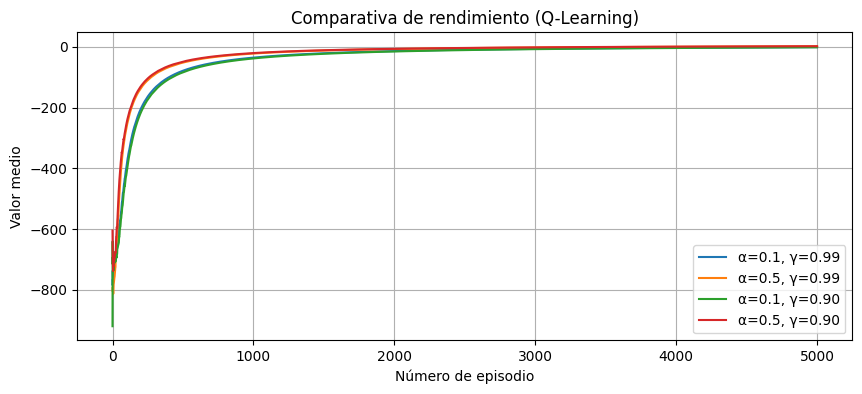

In [16]:
draw_multiple_learning_curves(dict_stats)

En la gráfica se observa que todas las configuraciones convergen hacia valores próximos a 0 en torno al episodio 2000, un resultado prácticamente idéntico al obtenido con SARSA. La mejor combinación sigue siendo $\alpha = 0.5$, $\gamma = 0.99$, lo que confirma que los patrones de sensibilidad a los hiperparámetros se mantienen entre ambos algoritmos.

Sin embargo, la vista ampliada de los primeros 1000 episodios revela una diferencia notable respecto a SARSA: las configuraciones con $\alpha = 0.5$ muestran una curva de aprendizaje inicial más pronunciada. Esto podemos interpretarlo como una consecuencia directa del enfoque off-policy, ya que al evaluar buscando siempre el máximo valor del estado siguiente, Q-Learning propaga el efecto de la recompensa final (+20) más que en el caso de SARSA.

Además, las curvas de Q-Learning presentan un perfil visiblemente más suave y menos ruidoso que las de SARSA. Esta menor varianza se explica porque Q-Learning reduce el efecto del ruido exploratorio porque aunque el taxi tome un desvío ineficiente, la función de valor no se degrada, ya que la actualización siempre se basa en la acción óptima teórica.

Ampliamos en los primeros episodios para poder analizar con más detalle los resultados:

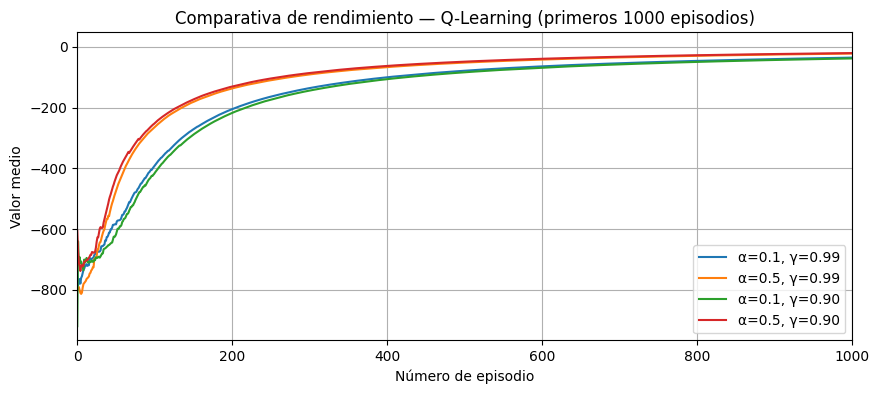

In [17]:
draw_multiple_learning_curves(dict_stats, limit=1000)

Al ampliar la gráfica vemos que existe una separación muy clara en dos grupos: las configuraciones con $\alpha = 0.5$ (naranja y roja) se despegan rápidamente del resto a partir del episodio 50, mientras que las de $\alpha = 0.1$ (azul y verde) ascienden de forma mucho más lenta.

Esto parece confirmar que $\alpha$ es el hiperparámetro dominante en la velocidad de convergencia en este caso, con un efecto que es incluso más notable que en SARSA.

Dentro de cada grupo, el efecto de $\gamma$ es prácticamente inexistente.

Estos resultados sugieren que el enfoque *off-policy* de Q-Learning amplifica el beneficio de un $\alpha$ alto. Podemos entenderlo como que al actualizar siempre con la acción óptima teórica, cada experiencia aporta más información útil y un paso de aprendizaje grande la aprovecha de forma más decisiva.

A continuación estudiamos las **longitudes de episodio**:

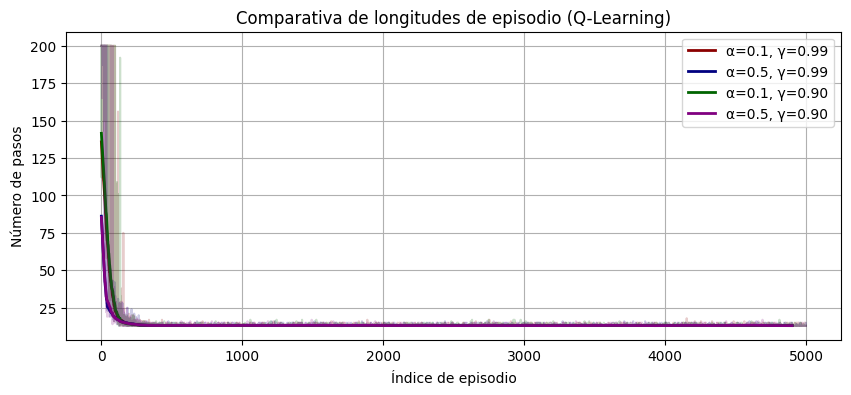

In [18]:
draw_episode_length_comparison(dict_len)

Estos resultados confirman la similitud general con SARSA. Todas las configuraciones convergen hacia un único numero de pasos, lo que parece indicar que se trata de la solución óptima. Además, la convergencia es extremadamente rápida, al igual que sucedía en el caso de SARSA.

Vamos a ampliar en los primeros episodios para poder analizarlo mejor



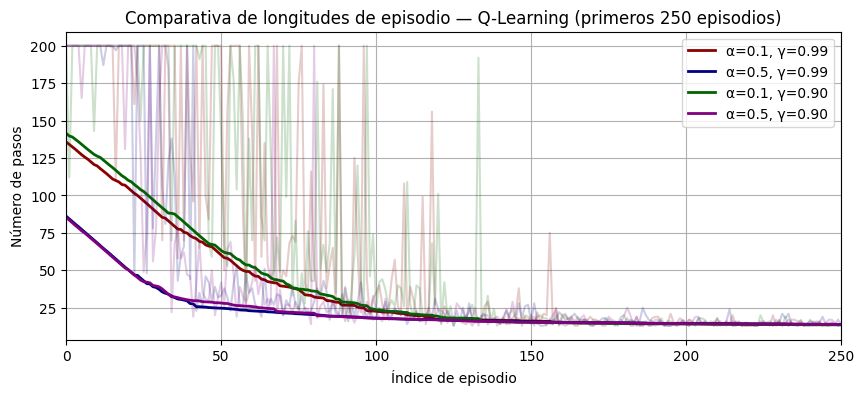

In [25]:
draw_episode_length_comparison(dict_len, limit=250)

Parece que el número de pasos disminuye hasta darse la convergencia en aproximadamente 15 pasos, lo que es coherente con lo visto en SARSA.

La mejor configuración de parámetros ha sido $α=0.5$ y $γ=0.99$, igual que en el caso de SARSA.

Además, en esta vista ampliada se aprecia que Q-Learning estabiliza el número de pasos mucho más rápido que SARSA, especialmente en las dos configuraciones con $\alpha = 0.5$, donde la caída por debajo de 25 pasos ocurre antes del episodio 150.

En cuanto al parámetro $γ$, parece intuirse que en las configuraciones con $γ=0.90$ tienen una convergencia ligeramente más lenta que su contraparte con $γ=0.99$, pero la diferencia no es lo suficientemente significativa como para poder afirmarlo con rotundidad.

En conjunto, la comparación entre ambos algoritmos en Taxi-v3 muestra que Q-Learning y SARSA alcanzan resultados finales equivalentes, pero Q-Learning presenta una convergencia inicial más rápida y una menor varianza en las ejecuciones.

No obstante, esta ventaja no es muy significativa en un entorno determinista sin zonas de penalización densa, donde la diferencia entre aprender desde la política de comportamiento o desde la política óptima teórica tenga una mayor relevancia. A modo de hipótesis, podriamos suponer que en un entorno con recompensas más variadas y con mayores recompensas negativas, la diferencia entre ambos algoritmos sería más marcada.

#### Visualización de la política aprendida
Ahora vamos a visualizar la política aprendida, usando las funciones auxiliares que muestran visualmente la política.

Para poder visualizar el comportamiento aprendido por el agente, se fija la posición del pasajero y el destino, representando únicamente la política asociada a esa sección concreta del espacio de estados. De esta forma, se construye un mapa 5×5 que muestra la acción greedy seleccionada por el agente para cada posición del taxi bajo esas condiciones fijas.

Es importante destacar que esta representación no muestra la política global del agente, sino una proyección bidimensional condicionada a un estado específico del pasajero y del destino.

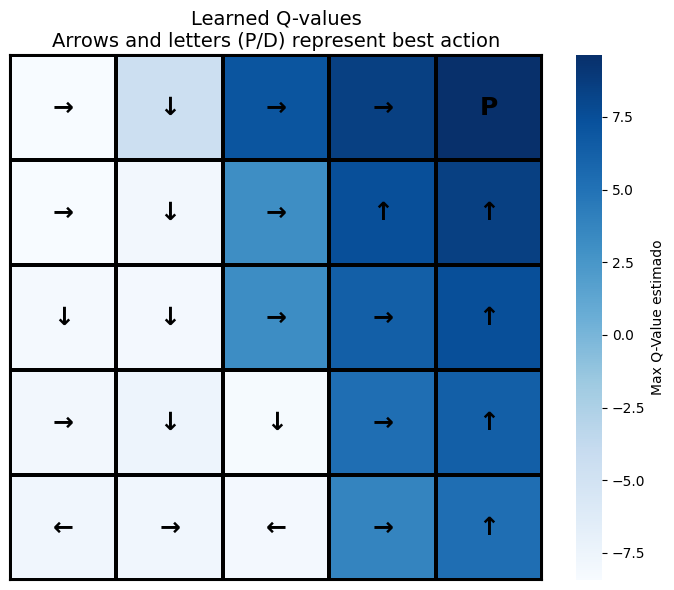

In [20]:
# Mostramos el mapa de la política aprendida para el mejor agente (α=0.5, γ=0.99)
plot_taxi_q_values_map(agent_a05_g099.get_q_values(), env)

En el diagrama se aprecia que el agente con la mejor configuración ($\alpha = 0.5$, $\gamma = 0.99$) muestra valores Q altos y coherentes, con flechas de dirección que reflejan claramente el intento de desplazarse hacia la posición del pasajero, lo que resulta correcto y demuestra que ha aprendido una buena política.

Finalmente, mostramos en un gif la ejecución del agente, para ilustrar el resultado logrado mediante el entrenamiento:

Episodio de prueba finalizado.
Recompensa total: 8.0
Pasos realizados: 13
Archivo guardado en: QL_Taxi_Optimal.gif



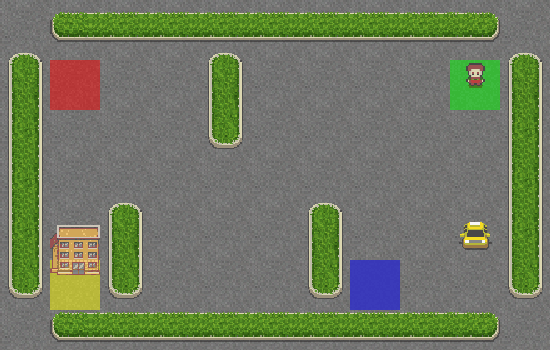

In [22]:
reward, len_episode, frames = capture_optimal_behavior(agent_a05_g099)

print(f"Episodio de prueba finalizado.")
print(f"Recompensa total: {reward}")
print(f"Pasos realizados: {len_episode}")

# Crear y mostrar el GIF
path_gif = "QL_Taxi_Optimal.gif"
create_gif_from_frames(frames, path_gif)
print("Archivo guardado en:", path_gif)
show_gif_in_notebook(path_gif)

## Conclusiones

Este experimento nos ha permitido evaluar Q-Learning bajo las mismas condiciones que SARSA, pudiendo comparar ambos enfoques dentro de la familia de métodos de diferencias temporales.

Hemos comprobado que la sensibilidad a los hiperparámetros sigue los mismos patrones que en el caso de SARSA: $\alpha$ es el factor dominante en la velocidad de convergencia y $\gamma = 0.99$ parece ofrecer un mejor resultado, pero muy marginal en este caso. La mejor combinación sigue siendo $\alpha = 0.5$, $\gamma = 0.99$.

La principal diferencia respecto a SARSA reside en la dinámica del aprendizaje. Q-Learning muestra una convergencia inicial más rápida (la separación entre configuraciones con $\alpha$ alto y bajo es más pronunciada que en SARSA) y curvas más suaves, consecuencia directa de que su actualización se basa siempre en la acción óptima teórica.

No obstante, los resultados finales son prácticamente idénticos, lo que indica que en un entorno determinista y sin zonas de penalización muy severas como Taxi-v3, la ventaja del enfoque *off-policy* que proporciona Q-learning es modesta.

A nuestro parecer, estos resultados sugieren que la elección entre SARSA y Q-Learning sería más determinante en entornos donde la exploración conlleva riesgos significativos (como *CliffWalking*, donde la prudencia *on-policy* de SARSA podría ser preferible), donde Q-Learning podría beneficiarse más de su capacidad para separar exploración y explotación.